shape of pt2 is (40, 3, 3, 3, 3, 8, 5, 7, 18)
cfg,smear_snk,smear_src,g_snk,g_src,tsrc,q,pf,tsep
shape of pt2 after selection is (40, 2, 2, 3, 3, 8, 5, 7, 18)
smearings used: ['N16 rho2.0', 'N40 rho3.25']
gammas used: ['G5', 'G45', 'G35']
checked: all 36 operator pairs match the file, so the labels below are true
shape of pt2 after merging is (40, 6, 6, 8, 5, 7, 18)   (cfg, op_snk, op_src, tsrc, q, pf, tsep)
operator 0: N16 G5
operator 1: N16 G45
operator 2: N16 G35
operator 3: N40 G5
operator 4: N40 G45
operator 5: N40 G35
jackknife samples: (40, 6, 6, 7, 18)   (sample, op_snk, op_src, pf, tsep)
forward: max over pf of |C_rec(t0) - 1| = 8.0e-15
backward: max over pf of |C_rec(t0) - 1| = 4.4e-15
pz 0: meff t = 1..8  0.2085 0.1582 0.1461 0.1425 0.1429 0.1423 0.1406 0.1418
pz 1: meff t = 1..8  0.3178 0.2630 0.2494 0.2413 0.2423 0.2413 0.2381 0.2438
pz 2: meff t = 1..8  0.5199 0.4532 0.4331 0.4237 0.4206 0.4156 0.4067 0.4276
pz 3: meff t = 1..8  0.7294 0.6536 0.6338 0.6250 0.6142 0.6274 0

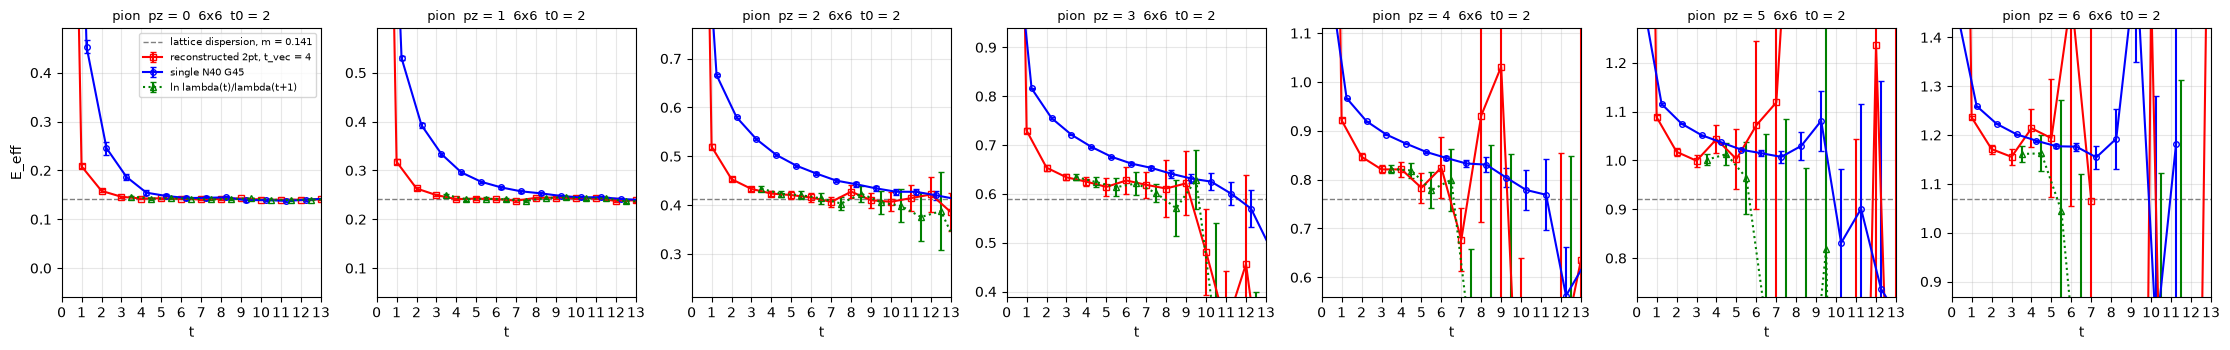

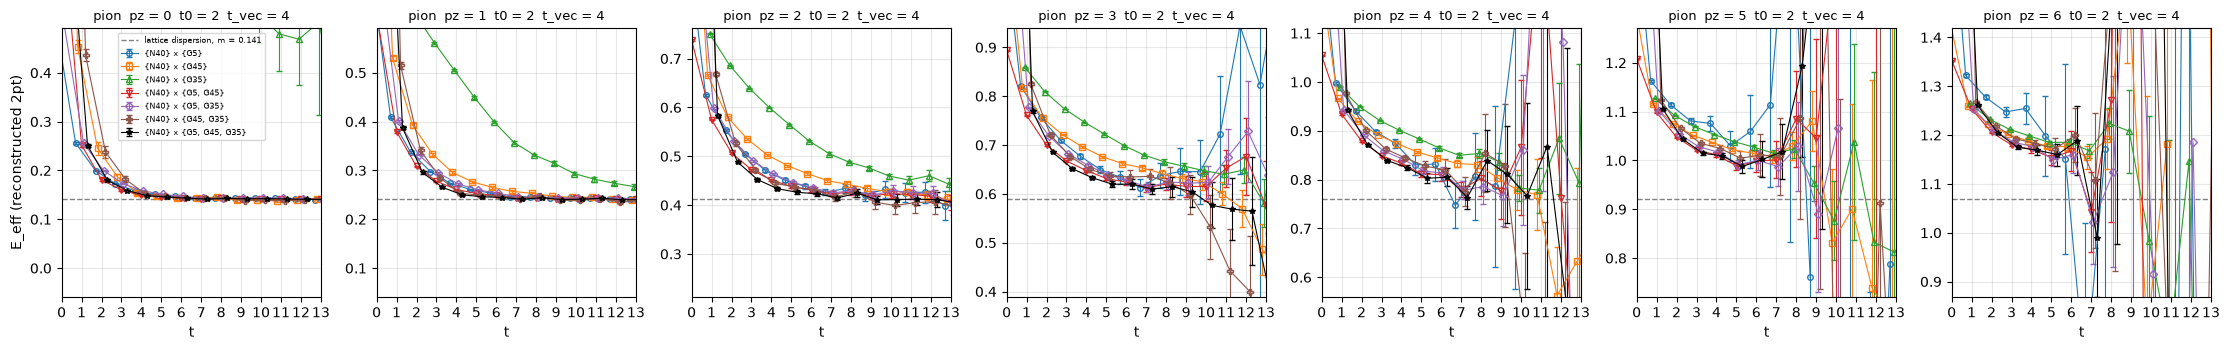

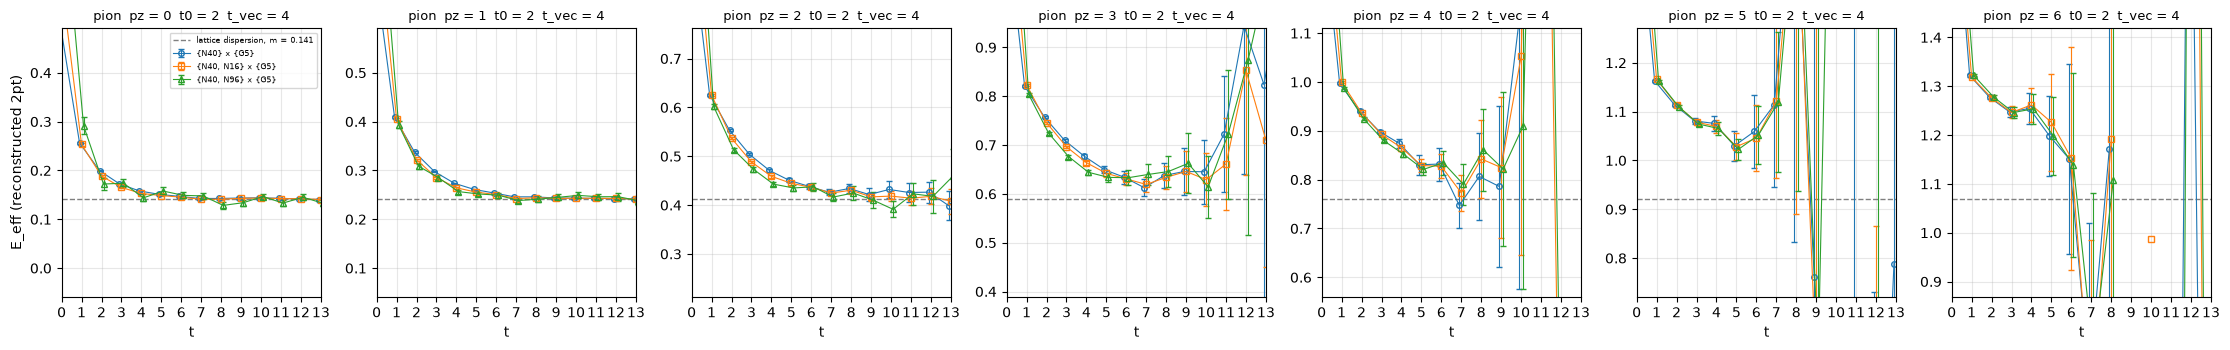

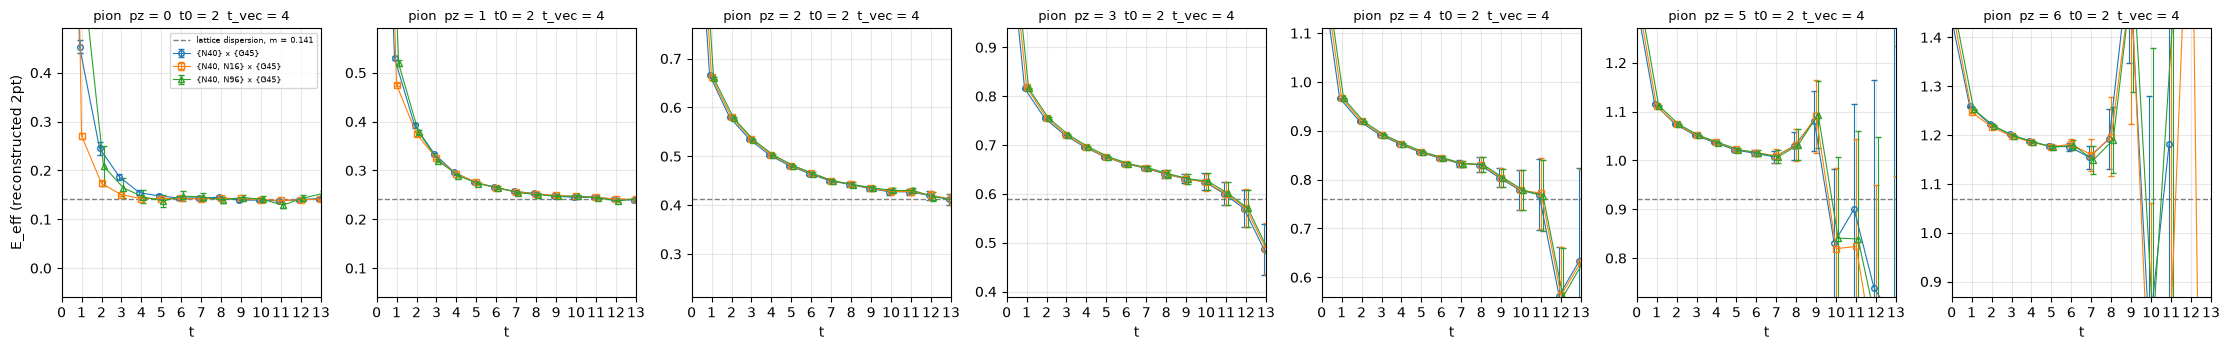

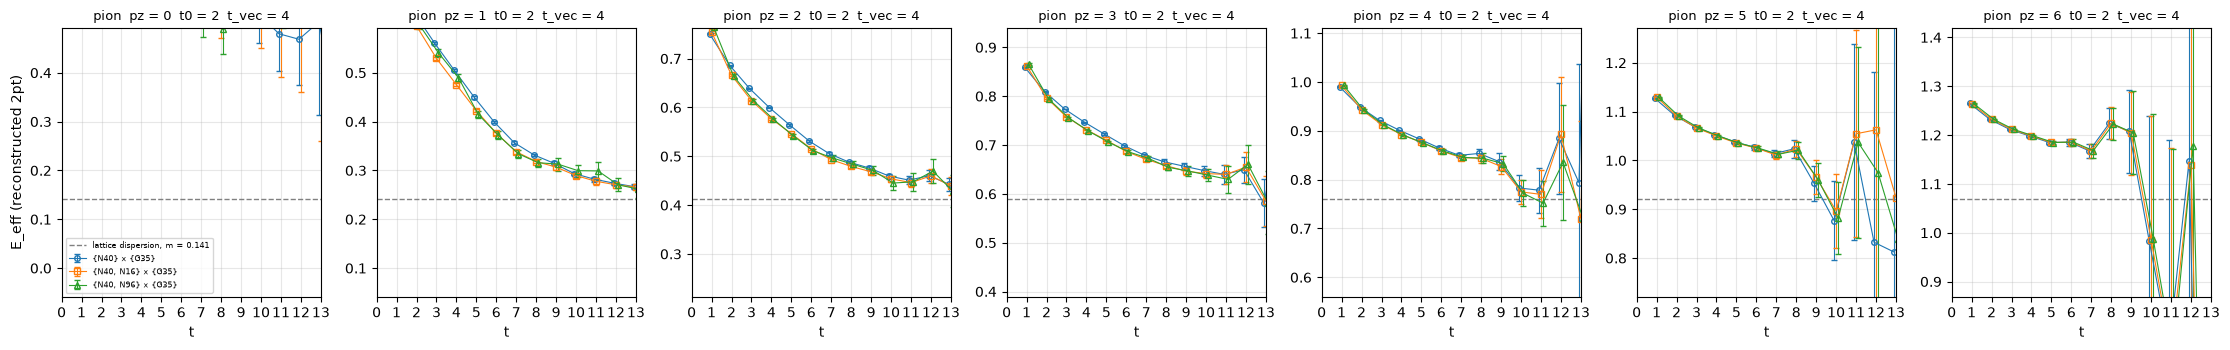

In [54]:
#old 3gamma*3smear isotropic version
import h5py
import numpy as np
import matplotlib.pyplot as plt

def jk(data, jk_axis=0):
    n = data.shape[jk_axis]
    data = np.moveaxis(data, jk_axis, 0)
    mean = np.mean(data, axis=0)
    err = np.sqrt((n - 1.0) / n * np.sum((data - mean) ** 2, axis=0))
    return mean, err

def solve_gevp(C_matrix):
    eigen_val = np.full((n_pf, n_op, len(t_list)), np.nan)
    eigen_vec = np.full((n_pf, n_op, len(t_list), n_op), np.nan, "<c16")
    for ipf in range(n_pf):
        L = np.linalg.cholesky(C_matrix[:, :, ipf, t0])
        L_inv = np.linalg.inv(L)
        for it, t in enumerate(t_list):
            M = L_inv @ C_matrix[:, :, ipf, t] @ L_inv.conj().T
            w, u = np.linalg.eigh(M)
            v = L_inv.conj().T @ u
            order = np.argsort(w)[::-1]
            eigen_val[ipf, :, it] = w[order]
            eigen_vec[ipf, :, it] = v[:, order].T
    return eigen_val, eigen_vec

local = "/Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis"
hadron = "pion"
smear_tag = "N16rho2.0_N40rho3.25_N96rho5.0"
pt2_path = f"{local}/2pt_{smear_tag}_GEVP_ez_momfrac0p6_{hadron}_tsrc_q5_fb_tsep18_64src_ncfg40.h5"

t0=2
t_vec=4
#smear 0 = N16, 1 = N40, 2 = N96;  gamma 0 = G5, 1 = G45, 2 = G35
smear_use = [0,1]
gamma_use = [0,1,2]
basis_tag = "smear" + "".join(str(s) for s in smear_use) + "_gamma" + "".join(str(g) for g in gamma_use)

with h5py.File(pt2_path, "r") as f:
    pt2_forward  = f["pt2_forward"][:]
    pt2_backward = f["pt2_backward"][:]
    pf_list  = f["pf_list"][:]
    q_list   = f["q_list"][:]
    cfg_list = f["cfg_list"][:]
    t_src_list = f["t_src_list"][:]
    smear_list = f["smear_list"][:]
    gamma_list = f.attrs["gamma_list"]
    dim_pt2 = f.attrs["dim_pt2"]

print(f"shape of pt2 is {pt2_forward.shape}")
print(f"cfg,smear_snk,smear_src,g_snk,g_src,tsrc,q,pf,tsep")

pt2_forward  = pt2_forward[:, smear_use][:, :, smear_use][:, :, :, gamma_use][:, :, :, :, gamma_use]
pt2_backward = pt2_backward[:, smear_use][:, :, smear_use][:, :, :, gamma_use][:, :, :, :, gamma_use]

print(f"shape of pt2 after selection is {pt2_forward.shape}")
print("smearings used:", [f"N{int(smear_list[s][0])} rho{smear_list[s][1]}" for s in smear_use])
print("gammas used:", [str(gamma_list[g]) for g in gamma_use])

n_cfg, n_smear, _, n_gamma, _, n_tsrc, n_q, n_pf, tsep_max = pt2_forward.shape
n_op = n_smear * n_gamma                    # 2 smearings x 3 gammas = 6 operators

#cfg, smear_sink, gamma_sink, smear_src, gamma_src
pt2_forward  = pt2_forward.transpose(0, 1, 3, 2, 4, 5, 6, 7, 8).reshape(n_cfg, n_op, n_op, n_tsrc, n_q, n_pf, tsep_max)
pt2_backward = pt2_backward.transpose(0, 1, 3, 2, 4, 5, 6, 7, 8).reshape(n_cfg, n_op, n_op, n_tsrc, n_q, n_pf, tsep_max)

# check: merged pt2_forward[:, a, b] must equal the stored element for the smear/gamma pair that op_labels names
op_pairs = [(s, g) for s in smear_use for g in gamma_use]          # same loop order as op_labels
with h5py.File(pt2_path, "r") as f:
    for a, (s_snk, g_snk) in enumerate(op_pairs):
        for b, (s_src, g_src) in enumerate(op_pairs):
            stored = f["pt2_forward"][:, s_snk, s_src, g_snk, g_src]     # file order: cfg, smear_snk, smear_src, g_snk, g_src, ...
            assert np.array_equal(pt2_forward[:, a, b], stored), f"operator pair ({a}, {b}) does not match the file"
print(f"checked: all {len(op_pairs) ** 2} operator pairs match the file, so the labels below are true")

print(f"shape of pt2 after merging is {pt2_forward.shape}   (cfg, op_snk, op_src, tsrc, q, pf, tsep)")
op_labels = [f"N{int(smear_list[s][0])} {gamma_list[g]}" for s in smear_use for g in gamma_use]
for a, label in enumerate(op_labels):
    print(f"operator {a}: {label}")


#take the q=0 elements
C = {}
C["forward"]  = pt2_forward[:, :, :, :, 0].mean(axis=3)       # (cfg, op_snk, op_src, pf, tsep)
C["backward"] = pt2_backward[:, :, :, :, 0].mean(axis=3)      # same; tsep counts backwards from the source
for half in ["forward", "backward"]:
    C[half] = 0.5 * (C[half] + np.conj(np.swapaxes(C[half], 1, 2)))
c_sign = -1 
for half in ["forward", "backward"]:
    C[half] = c_sign * C[half]
#build jackknife lists
C_mean, C_jk = {}, {}
for half in ["forward", "backward"]:
    C_mean[half] = C[half].mean(axis=0)                                               # (op, op, pf, tsep)
    C_jk[half] = (C[half].sum(axis=0)[None] - C[half]) / (n_cfg - 1)                  # (cfg, op, op, pf, tsep)
print(f"jackknife samples: {C_jk['forward'].shape}   (sample, op_snk, op_src, pf, tsep)")

t_list = np.arange(t0 + 1, tsep_max)
eigen_val_central, eigen_vec_central = {}, {}
for half in ["forward", "backward"]:
    eigen_val_central[half], eigen_vec_central[half] = solve_gevp(C_mean[half])

it_vec = list(t_list).index(t_vec)
v0 = {}
for half in ["forward", "backward"]:
    v0[half] = eigen_vec_central[half][:, 0, it_vec, :]

pt2_rec_mean = {}
for half in ["forward", "backward"]:
    pt2_rec_mean[half] = np.einsum("pa,abpT,pb->pT", np.conj(v0[half]), C_mean[half], v0[half])

for half in ["forward", "backward"]:
    deviation = np.abs(pt2_rec_mean[half][:, t0] - 1).max()
    print(f"{half}: max over pf of |C_rec(t0) - 1| = {deviation:.1e}")
    assert deviation < 1e-10, f"{half}: v0 is not normalized to v0^dag C(t0) v0 = 1"
pt2_rec = {}
pt2_rec["forward"] = pt2_rec_mean["forward"].real
pt2_rec["backward"] = pt2_rec_mean["backward"].real
pt2_rec["average"] = 0.5 * (pt2_rec["forward"] + pt2_rec["backward"])

meff = {}
with np.errstate(invalid="ignore", divide="ignore"):
    for half in ["forward", "backward", "average"]:
        meff[half] = np.log(pt2_rec[half][:, :-1] / pt2_rec[half][:, 1:])

for ipf in range(n_pf):
    print(f"pz {pf_list[ipf][2]}: meff t = 1..8  " + " ".join(f"{meff['average'][ipf, t]:.4f}" for t in range(1, 9)))

E_lambda = {}
with np.errstate(invalid="ignore", divide="ignore"):
    for half in ["forward", "backward"]:
        E_lambda[half] = np.log(eigen_val_central[half][:, 0, :-1] / eigen_val_central[half][:, 0, 1:])
E_lambda["average"] = 0.5 * (E_lambda["forward"] + E_lambda["backward"])
i_single = op_labels.index("N40 G45")
pt2_single = {}
for half in ["forward", "backward"]:
    pt2_single[half] = C_mean[half][i_single, i_single].real
pt2_single["average"] = 0.5 * (pt2_single["forward"] + pt2_single["backward"])
with np.errstate(invalid="ignore", divide="ignore"):
    meff_single = np.log(pt2_single["average"][:, :-1] / pt2_single["average"][:, 1:])
meff_err = {}
pt2_rec_jk = {}
for half in ["forward", "backward"]:
    pt2_rec_jk[half] = np.einsum("pa,cabpT,pb->cpT", np.conj(v0[half]), C_jk[half], v0[half]).real
pt2_rec_jk["average"] = 0.5 * (pt2_rec_jk["forward"] + pt2_rec_jk["backward"])
with np.errstate(invalid="ignore", divide="ignore"):
    meff_jk = np.log(pt2_rec_jk["average"][:, :, :-1] / pt2_rec_jk["average"][:, :, 1:])
meff_err["rec"] = jk(meff_jk)[1]

eigen_val_jk = {}
for half in ["forward", "backward"]:
    eigen_val_jk[half] = np.array([solve_gevp(C_jk[half][icfg])[0] for icfg in range(n_cfg)])
with np.errstate(invalid="ignore", divide="ignore"):
    E_lambda_jk = 0.5 * (np.log(eigen_val_jk["forward"][:, :, 0, :-1] / eigen_val_jk["forward"][:, :, 0, 1:])
                       + np.log(eigen_val_jk["backward"][:, :, 0, :-1] / eigen_val_jk["backward"][:, :, 0, 1:]))
meff_err["lambda"] = jk(E_lambda_jk)[1]

pt2_single_jk = 0.5 * (C_jk["forward"][:, i_single, i_single].real + C_jk["backward"][:, i_single, i_single].real)
with np.errstate(invalid="ignore", divide="ignore"):
    meff_single_jk = np.log(pt2_single_jk[:, :, :-1] / pt2_single_jk[:, :, 1:])
meff_err["single"] = jk(meff_single_jk)[1]
m_pi = 0.141
Ls = 32
t_meff = np.arange(tsep_max - 1)
plt.figure(figsize=(3.2 * n_pf, 3.6))
for ipf in range(n_pf):
    plt.subplot(1, n_pf, ipf + 1)
    p_lat = 2 * np.pi * pf_list[ipf][2] / Ls
    E_disp = 2 * np.arcsinh(np.sqrt(np.sinh(m_pi / 2) ** 2 + np.sin(p_lat / 2) ** 2))
    plt.axhline(E_disp, color="gray", lw=1, ls="--", label=f"lattice dispersion, m = {m_pi}")
    plt.errorbar(t_meff, meff["average"][ipf], yerr=meff_err["rec"][ipf], fmt="rs-", capsize=2, ms=4, mfc="none", label=f"reconstructed 2pt, t_vec = {t_vec}")
    plt.errorbar(t_meff+0.25, meff_single[ipf], yerr=meff_err["single"][ipf], fmt="bo-", capsize=2, ms=4, mfc="none", label=f"single {op_labels[i_single]}")
    plt.errorbar(t_list[:-1]+0.5, E_lambda["average"][ipf], yerr=meff_err["lambda"][ipf], fmt="g^:", capsize=2, ms=4, mfc="none", label="ln lambda(t)/lambda(t+1)")
    plt.ylim(E_disp - 0.2, E_disp + 0.35)
    plt.xlim(0, 13)
    plt.xticks(np.arange(0, 14))
    plt.grid(alpha=0.3)
    plt.title(f"{hadron}  pz = {pf_list[ipf][2]}  {n_op}x{n_op}  t0 = {t0}", fontsize=9)
    plt.xlabel("t")
    if ipf == 0:
        plt.ylabel("E_eff")
        plt.legend(fontsize=7)
plt.tight_layout()
plt.show()


#sergey's request
#smear 0 = N16, 1 = N40, 2 = N96;  gamma 0 = G5, 1 = G45, 2 = G35
basis_list_all = [{"{N40} x {G5}":           [[1], [0]],
                   "{N40} x {G45}":          [[1], [1]],
                   "{N40} x {G35}":          [[1], [2]],
                   "{N40} x {G5, G45}":      [[1], [0, 1]],
                   "{N40} x {G5, G35}":      [[1], [0, 2]],
                   "{N40} x {G45, G35}":     [[1], [1, 2]],
                   "{N40} x {G5, G45, G35}": [[1], [0, 1, 2]]},
                  {"{N40} x {G5}":           [[1], [0]],
                   "{N40, N16} x {G5}":      [[1, 0], [0]],
                   "{N40, N96} x {G5}":      [[1, 2], [0]]},
                  {"{N40} x {G45}":          [[1], [1]],
                   "{N40, N16} x {G45}":     [[1, 0], [1]],
                   "{N40, N96} x {G45}":     [[1, 2], [1]]},
                  {"{N40} x {G35}":          [[1], [2]],
                   "{N40, N16} x {G35}":     [[1, 0], [2]],
                   "{N40, N96} x {G35}":     [[1, 2], [2]]}]          # each dictionary is one figure; name: [smear_use, gamma_use]

with h5py.File(pt2_path, "r") as f:
    pt2_forward_file  = f["pt2_forward"][:]
    pt2_backward_file = f["pt2_backward"][:]

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "black", "tab:pink", "tab:olive", "tab:cyan"]
markers = ["o", "s", "^", "v", "D", "P", "*", "X", "<", ">"]

for basis_list in basis_list_all:
    meff_basis, meff_basis_err = {}, {}
    for name, (smear_use, gamma_use) in basis_list.items():
        # same steps as above, for this basis
        pt2_forward  = pt2_forward_file[:, smear_use][:, :, smear_use][:, :, :, gamma_use][:, :, :, :, gamma_use]
        pt2_backward = pt2_backward_file[:, smear_use][:, :, smear_use][:, :, :, gamma_use][:, :, :, :, gamma_use]
        n_cfg, n_smear, _, n_gamma, _, n_tsrc, n_q, n_pf, tsep_max = pt2_forward.shape
        n_op = n_smear * n_gamma
        pt2_forward  = pt2_forward.transpose(0, 1, 3, 2, 4, 5, 6, 7, 8).reshape(n_cfg, n_op, n_op, n_tsrc, n_q, n_pf, tsep_max)
        pt2_backward = pt2_backward.transpose(0, 1, 3, 2, 4, 5, 6, 7, 8).reshape(n_cfg, n_op, n_op, n_tsrc, n_q, n_pf, tsep_max)

        C = {}
        C["forward"]  = pt2_forward[:, :, :, :, 0].mean(axis=3)
        C["backward"] = pt2_backward[:, :, :, :, 0].mean(axis=3)
        for half in ["forward", "backward"]:
            C[half] = 0.5 * (C[half] + np.conj(np.swapaxes(C[half], 1, 2)))
            C[half] = c_sign * C[half]
        C_mean, C_jk = {}, {}
        for half in ["forward", "backward"]:
            C_mean[half] = C[half].mean(axis=0)
            C_jk[half] = (C[half].sum(axis=0)[None] - C[half]) / (n_cfg - 1)

        eigen_val_central, eigen_vec_central = {}, {}
        for half in ["forward", "backward"]:
            eigen_val_central[half], eigen_vec_central[half] = solve_gevp(C_mean[half])
        v0 = {}
        for half in ["forward", "backward"]:
            v0[half] = eigen_vec_central[half][:, 0, it_vec, :]

        pt2_rec_mean, pt2_rec_jk = {}, {}
        for half in ["forward", "backward"]:
            pt2_rec_mean[half] = np.einsum("pa,abpT,pb->pT", np.conj(v0[half]), C_mean[half], v0[half]).real
            pt2_rec_jk[half] = np.einsum("pa,cabpT,pb->cpT", np.conj(v0[half]), C_jk[half], v0[half]).real
        pt2_rec_mean["average"] = 0.5 * (pt2_rec_mean["forward"] + pt2_rec_mean["backward"])
        pt2_rec_jk["average"] = 0.5 * (pt2_rec_jk["forward"] + pt2_rec_jk["backward"])
        with np.errstate(invalid="ignore", divide="ignore"):
            meff_basis[name] = np.log(pt2_rec_mean["average"][:, :-1] / pt2_rec_mean["average"][:, 1:])
            meff_basis_err[name] = jk(np.log(pt2_rec_jk["average"][:, :, :-1] / pt2_rec_jk["average"][:, :, 1:]))[1]

    plt.figure(figsize=(3.2 * n_pf, 3.6))
    n_basis = len(basis_list)
    for ipf in range(n_pf):
        plt.subplot(1, n_pf, ipf + 1)
        p_lat = 2 * np.pi * pf_list[ipf][2] / Ls
        E_disp = 2 * np.arcsinh(np.sqrt(np.sinh(m_pi / 2) ** 2 + np.sin(p_lat / 2) ** 2))
        plt.axhline(E_disp, color="gray", lw=1, ls="--", label=f"lattice dispersion, m = {m_pi}")
        for i, name in enumerate(basis_list):
            shift = 0.1 * (i - (n_basis - 1) / 2)
            plt.errorbar(t_meff + shift, meff_basis[name][ipf], yerr=meff_basis_err[name][ipf], fmt=markers[i % 10] + "-",
                         color=colors[i % 10], capsize=2, ms=4, mfc="none", lw=0.8, label=name)
        plt.ylim(E_disp - 0.2, E_disp + 0.35)
        plt.xlim(0, 13)
        plt.xticks(np.arange(0, 14))
        plt.grid(alpha=0.3)
        plt.title(f"{hadron}  pz = {pf_list[ipf][2]}  t0 = {t0}  t_vec = {t_vec}", fontsize=9)
        plt.xlabel("t")
        if ipf == 0:
            plt.ylabel("E_eff (reconstructed 2pt)")
            plt.legend(fontsize=6)
    plt.tight_layout()
    plt.show()

shape of pt2 is (40, 2, 2, 2, 2, 2, 2, 8, 1, 7, 20)
cfg,shape_snk,shape_src,frac_snk,frac_src,g_snk,g_src,tsrc,q,pf,tsep
shape of pt2 after selection is (40, 2, 2, 1, 1, 2, 2, 8, 1, 7, 20)
shapes used: ['iso rho_T 3.25 rho_z 3.25', 'aniso rho_T 3.25 rho_z 1.625']
boosts used: ['frac 0.3']
gammas used: ['G5', 'G45']
checked: all 16 operator pairs match the file, so the labels below are true
shape of pt2 after merging is (40, 4, 4, 8, 1, 7, 20)   (cfg, op_snk, op_src, tsrc, q, pf, tsep)
operator 0: iso frac0.3 G5
operator 1: iso frac0.3 G45
operator 2: aniso frac0.3 G5
operator 3: aniso frac0.3 G45
jackknife samples: (40, 4, 4, 7, 20)   (sample, op_snk, op_src, pf, tsep)
forward: max over pf of |C_rec(t0) - 1| = 6.7e-16
backward: max over pf of |C_rec(t0) - 1| = 6.7e-16
pz 0: meff t = 1..8  0.2535 0.1759 0.1526 0.1461 0.1444 0.1439 0.1421 0.1434
pz 1: meff t = 1..8  0.3780 0.3040 0.2732 0.2590 0.2522 0.2488 0.2424 0.2451
pz 2: meff t = 1..8  0.5839 0.5089 0.4711 0.4506 0.4336 0.4350 0.41

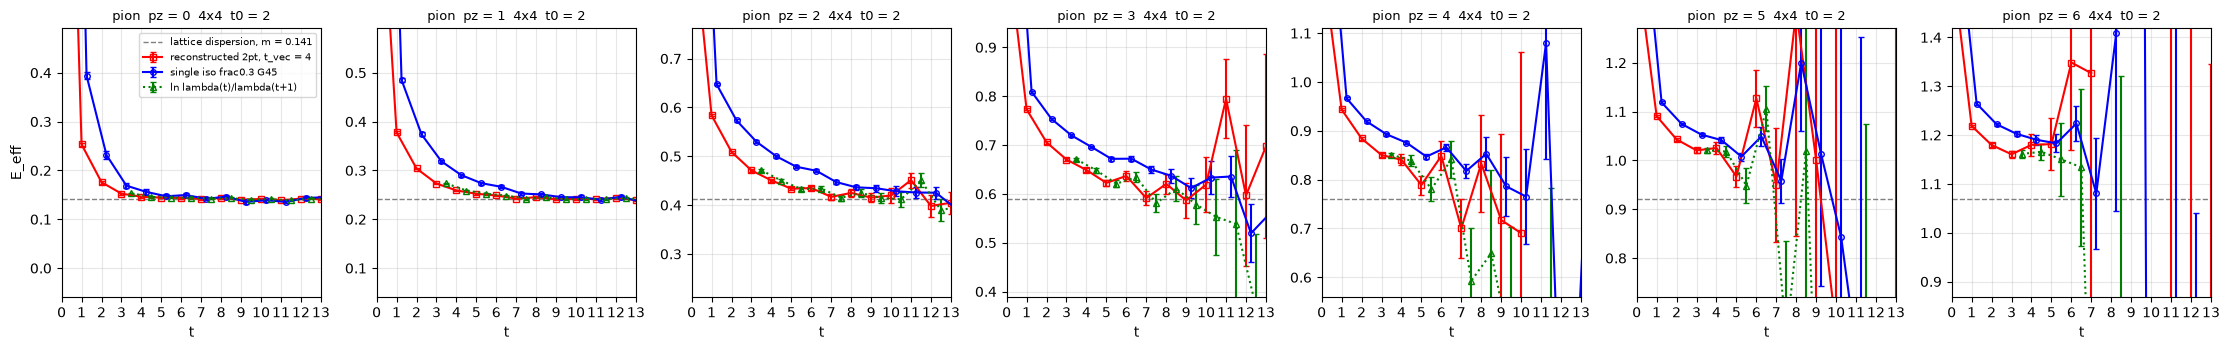

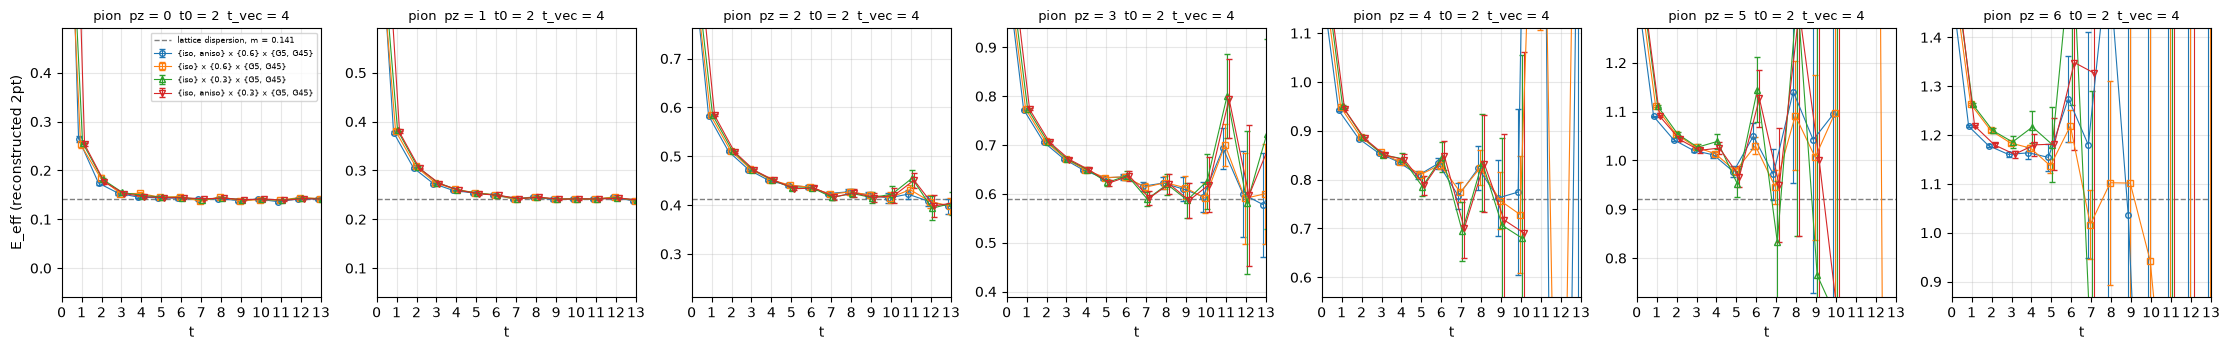

In [64]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def jk(data, jk_axis=0):
    n = data.shape[jk_axis]
    data = np.moveaxis(data, jk_axis, 0)
    mean = np.mean(data, axis=0)
    err = np.sqrt((n - 1.0) / n * np.sum((data - mean) ** 2, axis=0))
    return mean, err

def solve_gevp(C_matrix):
    eigen_val = np.full((n_pf, n_op, len(t_list)), np.nan)
    eigen_vec = np.full((n_pf, n_op, len(t_list), n_op), np.nan, "<c16")
    for ipf in range(n_pf):
        L = np.linalg.cholesky(C_matrix[:, :, ipf, t0])
        L_inv = np.linalg.inv(L)
        for it, t in enumerate(t_list):
            M = L_inv @ C_matrix[:, :, ipf, t] @ L_inv.conj().T
            w, u = np.linalg.eigh(M)
            v = L_inv.conj().T @ u
            order = np.argsort(w)[::-1]
            eigen_val[ipf, :, it] = w[order]
            eigen_vec[ipf, :, it] = v[:, order].T
    return eigen_val, eigen_vec

local = "/Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis"
hadron = "pion"
smear_tag = "coulomb_rhoT3.25_iso-aniso_frac0p6-0p3"
pt2_path = f"{local}/2pt_{smear_tag}_GEVP_qsrc_physp_{hadron}_tsrc_q1_fb_tsep20_64src_ncfg40.h5"

t0 = 2
t_vec = 4
#shape 0 = iso, 1 = aniso;  frac 0 = boost 0.6, 1 = boost 0.3;  gamma 0 = G5, 1 = G45
shape_use = [0,1]
frac_use = [1]
gamma_use = [0, 1]

with h5py.File(pt2_path, "r") as f:
    pt2_forward  = f["pt2_forward"][:]
    pt2_backward = f["pt2_backward"][:]
    pf_list  = f["pf_list"][:]
    shape_list = f["shape_list"][:]
    mom_frac_list = f["mom_frac_list"][:]
    shape_names = f.attrs["shape_names"]
    gamma_list = f.attrs["gamma_list"]

print(f"shape of pt2 is {pt2_forward.shape}")
print("cfg,shape_snk,shape_src,frac_snk,frac_src,g_snk,g_src,tsrc,q,pf,tsep")

pt2_forward  = pt2_forward[:, shape_use][:, :, shape_use][:, :, :, frac_use][:, :, :, :, frac_use][:, :, :, :, :, gamma_use][:, :, :, :, :, :, gamma_use]
pt2_backward = pt2_backward[:, shape_use][:, :, shape_use][:, :, :, frac_use][:, :, :, :, frac_use][:, :, :, :, :, gamma_use][:, :, :, :, :, :, gamma_use]

print(f"shape of pt2 after selection is {pt2_forward.shape}")
print("shapes used:", [f"{shape_names[s]} rho_T {shape_list[s][0]} rho_z {shape_list[s][1]}" for s in shape_use])
print("boosts used:", [f"frac {mom_frac_list[fr]}" for fr in frac_use])
print("gammas used:", [str(gamma_list[g]) for g in gamma_use])

n_cfg, n_shape, _, n_frac, _, n_gamma, _, n_tsrc, n_q, n_pf, tsep_max = pt2_forward.shape
n_op = n_shape * n_frac * n_gamma

#cfg, shape_sink, frac_sink, gamma_sink, shape_src, frac_src, gamma_src
pt2_forward  = pt2_forward.transpose(0, 1, 3, 5, 2, 4, 6, 7, 8, 9, 10).reshape(n_cfg, n_op, n_op, n_tsrc, n_q, n_pf, tsep_max)
pt2_backward = pt2_backward.transpose(0, 1, 3, 5, 2, 4, 6, 7, 8, 9, 10).reshape(n_cfg, n_op, n_op, n_tsrc, n_q, n_pf, tsep_max)

# check: merged pt2_forward[:, a, b] must equal the stored element for the shape/frac/gamma triple that op_labels names
op_triples = [(s, fr, g) for s in shape_use for fr in frac_use for g in gamma_use]          # same loop order as op_labels
with h5py.File(pt2_path, "r") as f:
    for a, (s_snk, fr_snk, g_snk) in enumerate(op_triples):
        for b, (s_src, fr_src, g_src) in enumerate(op_triples):
            stored = f["pt2_forward"][:, s_snk, s_src, fr_snk, fr_src, g_snk, g_src]     # file order: cfg, shape_snk, shape_src, frac_snk, frac_src, g_snk, g_src, ...
            assert np.array_equal(pt2_forward[:, a, b], stored), f"operator pair ({a}, {b}) does not match the file"
print(f"checked: all {len(op_triples) ** 2} operator pairs match the file, so the labels below are true")

print(f"shape of pt2 after merging is {pt2_forward.shape}   (cfg, op_snk, op_src, tsrc, q, pf, tsep)")
op_labels = [f"{shape_names[s]} frac{mom_frac_list[fr]} {gamma_list[g]}" for s in shape_use for fr in frac_use for g in gamma_use]
for a, label in enumerate(op_labels):
    print(f"operator {a}: {label}")


#take the q=0 elements
C = {}
C["forward"]  = pt2_forward[:, :, :, :, 0].mean(axis=3)       # (cfg, op_snk, op_src, pf, tsep)
C["backward"] = pt2_backward[:, :, :, :, 0].mean(axis=3)      # same; tsep counts backwards from the source
for half in ["forward", "backward"]:
    C[half] = 0.5 * (C[half] + np.conj(np.swapaxes(C[half], 1, 2)))
c_sign = -1
for half in ["forward", "backward"]:
    C[half] = c_sign * C[half]
#build jackknife lists
C_mean, C_jk = {}, {}
for half in ["forward", "backward"]:
    C_mean[half] = C[half].mean(axis=0)                                               # (op, op, pf, tsep)
    C_jk[half] = (C[half].sum(axis=0)[None] - C[half]) / (n_cfg - 1)                  # (cfg, op, op, pf, tsep)
print(f"jackknife samples: {C_jk['forward'].shape}   (sample, op_snk, op_src, pf, tsep)")

t_list = np.arange(t0 + 1, tsep_max)
eigen_val_central, eigen_vec_central = {}, {}
for half in ["forward", "backward"]:
    eigen_val_central[half], eigen_vec_central[half] = solve_gevp(C_mean[half])

it_vec = list(t_list).index(t_vec)
v0 = {}
for half in ["forward", "backward"]:
    v0[half] = eigen_vec_central[half][:, 0, it_vec, :]

pt2_rec_mean = {}
for half in ["forward", "backward"]:
    pt2_rec_mean[half] = np.einsum("pa,abpT,pb->pT", np.conj(v0[half]), C_mean[half], v0[half])

for half in ["forward", "backward"]:
    deviation = np.abs(pt2_rec_mean[half][:, t0] - 1).max()
    print(f"{half}: max over pf of |C_rec(t0) - 1| = {deviation:.1e}")
    assert deviation < 1e-10, f"{half}: v0 is not normalized to v0^dag C(t0) v0 = 1"
pt2_rec = {}
pt2_rec["forward"] = pt2_rec_mean["forward"].real
pt2_rec["backward"] = pt2_rec_mean["backward"].real
pt2_rec["average"] = 0.5 * (pt2_rec["forward"] + pt2_rec["backward"])

meff = {}
with np.errstate(invalid="ignore", divide="ignore"):
    for half in ["forward", "backward", "average"]:
        meff[half] = np.log(pt2_rec[half][:, :-1] / pt2_rec[half][:, 1:])

for ipf in range(n_pf):
    print(f"pz {pf_list[ipf][2]}: meff t = 1..8  " + " ".join(f"{meff['average'][ipf, t]:.4f}" for t in range(1, 9)))

E_lambda = {}
with np.errstate(invalid="ignore", divide="ignore"):
    for half in ["forward", "backward"]:
        E_lambda[half] = np.log(eigen_val_central[half][:, 0, :-1] / eigen_val_central[half][:, 0, 1:])
E_lambda["average"] = 0.5 * (E_lambda["forward"] + E_lambda["backward"])
i_single = op_labels.index(f"iso frac{mom_frac_list[frac_use[0]]} G45")
pt2_single = {}
for half in ["forward", "backward"]:
    pt2_single[half] = C_mean[half][i_single, i_single].real
pt2_single["average"] = 0.5 * (pt2_single["forward"] + pt2_single["backward"])
with np.errstate(invalid="ignore", divide="ignore"):
    meff_single = np.log(pt2_single["average"][:, :-1] / pt2_single["average"][:, 1:])
meff_err = {}
pt2_rec_jk = {}
for half in ["forward", "backward"]:
    pt2_rec_jk[half] = np.einsum("pa,cabpT,pb->cpT", np.conj(v0[half]), C_jk[half], v0[half]).real
pt2_rec_jk["average"] = 0.5 * (pt2_rec_jk["forward"] + pt2_rec_jk["backward"])
with np.errstate(invalid="ignore", divide="ignore"):
    meff_jk = np.log(pt2_rec_jk["average"][:, :, :-1] / pt2_rec_jk["average"][:, :, 1:])
meff_err["rec"] = jk(meff_jk)[1]

eigen_val_jk = {}
for half in ["forward", "backward"]:
    eigen_val_jk[half] = np.array([solve_gevp(C_jk[half][icfg])[0] for icfg in range(n_cfg)])
with np.errstate(invalid="ignore", divide="ignore"):
    E_lambda_jk = 0.5 * (np.log(eigen_val_jk["forward"][:, :, 0, :-1] / eigen_val_jk["forward"][:, :, 0, 1:])
                       + np.log(eigen_val_jk["backward"][:, :, 0, :-1] / eigen_val_jk["backward"][:, :, 0, 1:]))
meff_err["lambda"] = jk(E_lambda_jk)[1]

pt2_single_jk = 0.5 * (C_jk["forward"][:, i_single, i_single].real + C_jk["backward"][:, i_single, i_single].real)
with np.errstate(invalid="ignore", divide="ignore"):
    meff_single_jk = np.log(pt2_single_jk[:, :, :-1] / pt2_single_jk[:, :, 1:])
meff_err["single"] = jk(meff_single_jk)[1]
m_pi = 0.141
Ls = 32
t_meff = np.arange(tsep_max - 1)
plt.figure(figsize=(3.2 * n_pf, 3.6))
for ipf in range(n_pf):
    plt.subplot(1, n_pf, ipf + 1)
    p_lat = 2 * np.pi * pf_list[ipf][2] / Ls
    E_disp = 2 * np.arcsinh(np.sqrt(np.sinh(m_pi / 2) ** 2 + np.sin(p_lat / 2) ** 2))
    plt.axhline(E_disp, color="gray", lw=1, ls="--", label=f"lattice dispersion, m = {m_pi}")
    plt.errorbar(t_meff, meff["average"][ipf], yerr=meff_err["rec"][ipf], fmt="rs-", capsize=2, ms=4, mfc="none", label=f"reconstructed 2pt, t_vec = {t_vec}")
    plt.errorbar(t_meff+0.25, meff_single[ipf], yerr=meff_err["single"][ipf], fmt="bo-", capsize=2, ms=4, mfc="none", label=f"single {op_labels[i_single]}")
    plt.errorbar(t_list[:-1]+0.5, E_lambda["average"][ipf], yerr=meff_err["lambda"][ipf], fmt="g^:", capsize=2, ms=4, mfc="none", label="ln lambda(t)/lambda(t+1)")
    plt.ylim(E_disp - 0.2, E_disp + 0.35)
    plt.xlim(0, 13)
    plt.xticks(np.arange(0, 14))
    plt.grid(alpha=0.3)
    plt.title(f"{hadron}  pz = {pf_list[ipf][2]}  {n_op}x{n_op}  t0 = {t0}", fontsize=9)
    plt.xlabel("t")
    if ipf == 0:
        plt.ylabel("E_eff")
        plt.legend(fontsize=7)
plt.tight_layout()
plt.show()


#shape 0 = iso, 1 = aniso;  frac 0 = boost 0.6, 1 = boost 0.3;  gamma 0 = G5, 1 = G45
basis_list_all = [{"{iso, aniso} x {0.6} x {G5, G45}": [[0, 1], [0], [0, 1]],
                   "{iso} x {0.6} x {G5, G45}":        [[0], [0], [0, 1]],
                   "{iso} x {0.3} x {G5, G45}":        [[0], [1], [0, 1]],
                   "{iso, aniso} x {0.3} x {G5, G45}": [[0, 1], [1], [0, 1]]}]         
with h5py.File(pt2_path, "r") as f:
    pt2_forward_file  = f["pt2_forward"][:]
    pt2_backward_file = f["pt2_backward"][:]

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "black", "tab:pink", "tab:olive", "tab:cyan"]
markers = ["o", "s", "^", "v", "D", "P", "*", "X", "<", ">"]

for basis_list in basis_list_all:
    meff_basis, meff_basis_err = {}, {}
    for name, (shape_use, frac_use, gamma_use) in basis_list.items():
        # same steps as above, for this basis
        pt2_forward  = pt2_forward_file[:, shape_use][:, :, shape_use][:, :, :, frac_use][:, :, :, :, frac_use][:, :, :, :, :, gamma_use][:, :, :, :, :, :, gamma_use]
        pt2_backward = pt2_backward_file[:, shape_use][:, :, shape_use][:, :, :, frac_use][:, :, :, :, frac_use][:, :, :, :, :, gamma_use][:, :, :, :, :, :, gamma_use]
        n_cfg, n_shape, _, n_frac, _, n_gamma, _, n_tsrc, n_q, n_pf, tsep_max = pt2_forward.shape
        n_op = n_shape * n_frac * n_gamma
        pt2_forward  = pt2_forward.transpose(0, 1, 3, 5, 2, 4, 6, 7, 8, 9, 10).reshape(n_cfg, n_op, n_op, n_tsrc, n_q, n_pf, tsep_max)
        pt2_backward = pt2_backward.transpose(0, 1, 3, 5, 2, 4, 6, 7, 8, 9, 10).reshape(n_cfg, n_op, n_op, n_tsrc, n_q, n_pf, tsep_max)

        C = {}
        C["forward"]  = pt2_forward[:, :, :, :, 0].mean(axis=3)
        C["backward"] = pt2_backward[:, :, :, :, 0].mean(axis=3)
        for half in ["forward", "backward"]:
            C[half] = 0.5 * (C[half] + np.conj(np.swapaxes(C[half], 1, 2)))
            C[half] = c_sign * C[half]
        C_mean, C_jk = {}, {}
        for half in ["forward", "backward"]:
            C_mean[half] = C[half].mean(axis=0)
            C_jk[half] = (C[half].sum(axis=0)[None] - C[half]) / (n_cfg - 1)

        eigen_val_central, eigen_vec_central = {}, {}
        for half in ["forward", "backward"]:
            eigen_val_central[half], eigen_vec_central[half] = solve_gevp(C_mean[half])
        v0 = {}
        for half in ["forward", "backward"]:
            v0[half] = eigen_vec_central[half][:, 0, it_vec, :]

        pt2_rec_mean, pt2_rec_jk = {}, {}
        for half in ["forward", "backward"]:
            pt2_rec_mean[half] = np.einsum("pa,abpT,pb->pT", np.conj(v0[half]), C_mean[half], v0[half]).real
            pt2_rec_jk[half] = np.einsum("pa,cabpT,pb->cpT", np.conj(v0[half]), C_jk[half], v0[half]).real
        pt2_rec_mean["average"] = 0.5 * (pt2_rec_mean["forward"] + pt2_rec_mean["backward"])
        pt2_rec_jk["average"] = 0.5 * (pt2_rec_jk["forward"] + pt2_rec_jk["backward"])
        with np.errstate(invalid="ignore", divide="ignore"):
            meff_basis[name] = np.log(pt2_rec_mean["average"][:, :-1] / pt2_rec_mean["average"][:, 1:])
            meff_basis_err[name] = jk(np.log(pt2_rec_jk["average"][:, :, :-1] / pt2_rec_jk["average"][:, :, 1:]))[1]

    plt.figure(figsize=(3.2 * n_pf, 3.6))
    n_basis = len(basis_list)
    for ipf in range(n_pf):
        plt.subplot(1, n_pf, ipf + 1)
        p_lat = 2 * np.pi * pf_list[ipf][2] / Ls
        E_disp = 2 * np.arcsinh(np.sqrt(np.sinh(m_pi / 2) ** 2 + np.sin(p_lat / 2) ** 2))
        plt.axhline(E_disp, color="gray", lw=1, ls="--", label=f"lattice dispersion, m = {m_pi}")
        for i, name in enumerate(basis_list):
            shift = 0.1 * (i - (n_basis - 1) / 2)
            plt.errorbar(t_meff + shift, meff_basis[name][ipf], yerr=meff_basis_err[name][ipf], fmt=markers[i % 10] + "-",
                         color=colors[i % 10], capsize=2, ms=4, mfc="none", lw=0.8, label=name)
        plt.ylim(E_disp - 0.2, E_disp + 0.35)
        plt.xlim(0, 13)
        plt.xticks(np.arange(0, 14))
        plt.grid(alpha=0.3)
        plt.title(f"{hadron}  pz = {pf_list[ipf][2]}  t0 = {t0}  t_vec = {t_vec}", fontsize=9)
        plt.xlabel("t")
        if ipf == 0:
            plt.ylabel("E_eff (reconstructed 2pt)")
            plt.legend(fontsize=6)
    plt.tight_layout()
    plt.show()

In [64]:
import h5py
import numpy as np
from opt_einsum import contract

def jackknife(x):
    n_cfg = x.shape[0]
    return (x.sum(axis=0) - x) / (n_cfg - 1)

F_or_B = "forward"
q_tag = "q000"
hyp_tag = "0-15"
pt2_choice = "gevp"            # "gevp": reconstructed 2pt;  "N40G45": single-operator diagonal from the same run, for comparison
pt2_tag = "smear2222222_t02_tref4"
local = "/Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis"
FF_path = f"{local}/FF_streamd_hyp{hyp_tag}_{q_tag}_fb_tins18_64src_ncfg40.h5"
gevp_path = f"{local}/2pt_reconstructed_pion_{pt2_tag}_64src_ncfg40.h5"
raw_path = f"{local}/2pt_N16rho2.0_N40rho3.25_N96rho5.0_GEVP_ez_momfrac0p6_pion_tsrc_q5_fb_tsep18_64src_ncfg40.h5"
Ls = 32
WL_PHASE_SIGN = +1     # Fix the centering of Wilson line (trivial at q = 0)

FF_file = h5py.File(FF_path, "r")
FF_cfg = FF_file[f"FF_{F_or_B}"]                         # [cfg, tsrc, munu, rhosig, hyp, w, q, tau] = (40, 8, 6, 6, 16, 16, 1, 18)
q_list = FF_file["q_list"][:]                            # [[0, 0, 0]]
w_list = FF_file["w_list"][:]
hyp_list = FF_file["hyp_list"][:]
cfg_list = FF_file["cfg_list"][:]
print(FF_cfg.shape)

# 2pt: already phase-weighted and averaged over the spatial source positions on the cluster -> [cfg, tsrc, q, pf, tsep]
if pt2_choice == "gevp":
    pt2_file = h5py.File(gevp_path, "r")
    pt2_all = pt2_file[f"pt2_{F_or_B}"][:]                       # [cfg, tsrc, q, pf, tsep] = (40, 8, 5, 7, 18)
else:
    pt2_file = h5py.File(raw_path, "r")
    pt2_all = pt2_file[f"pt2_{F_or_B}"][:, 1, 1, 1, 1]           # smear_sink = smear_src = N40, gamma_sink = gamma_src = G45
q_list_pt2 = pt2_file["q_list"][:]
pf_list = pt2_file["pf_list"][:]
assert np.array_equal(pt2_file["cfg_list"][:], cfg_list)
assert np.array_equal(pt2_file["t_src_list"][:], FF_file["t_src_list"][:])
iq = [int(np.where((q_list_pt2 == q).all(axis=1))[0][0]) for q in q_list]   # position of each FF q in the 2pt q_list
pt2_src = pt2_all[:, :, iq].transpose(0, 1, 3, 4, 2)                          # [cfg, tsrc, pf, tsep, q] = (40, 8, 7, 18, 1)
n_cfg, n_tsrc = pt2_src.shape[:2]
print(pt2_src.shape)

#In my FF production code, Wilson line is not from -w/2 to w/2 so we need an extra phase factor to restore the convention (exactly)
wl_phase = np.exp(WL_PHASE_SIGN * 1j * np.pi / Ls * contract(w_list, ["w"], q_list[:, 2], ["q"], ["w", "q"]))    # [w, q] = (16, 1)
TXTX = contract(FF_cfg[:, :, 3, 3], ["cfg", "tsrc", "hyp", "w", "q", "tau"], wl_phase, ["w", "q"], ["cfg", "tsrc", "hyp", "w", "q", "tau"])
TYTY = contract(FF_cfg[:, :, 4, 4], ["cfg", "tsrc", "hyp", "w", "q", "tau"], wl_phase, ["w", "q"], ["cfg", "tsrc", "hyp", "w", "q", "tau"])
XYXY = contract(FF_cfg[:, :, 0, 0], ["cfg", "tsrc", "hyp", "w", "q", "tau"], wl_phase, ["w", "q"], ["cfg", "tsrc", "hyp", "w", "q", "tau"])
TXTXpTYTY = TXTX + TYTY
TXTXpTYTYm2XYXY = TXTXpTYTY - 2 * XYXY
TXTXpTYTYp2XYXY = TXTXpTYTY + 2 * XYXY
operators = [TXTX, TYTY, XYXY, TXTXpTYTY, TXTXpTYTYm2XYXY, TXTXpTYTYp2XYXY]
op_names = ["TXTX", "TYTY", "XYXY", "TXTXpTYTY", "TXTXpTYTYm2XYXY", "TXTXpTYTYp2XYXY"]

#Calculate the connected piece
pt2FF = []
for iop, op in enumerate(operators):
    print(iop)
    connected_term = contract(pt2_src, ["cfg", "tsrc", "pf", "tsep", "q"],
                              op,      ["cfg", "tsrc", "hyp", "w", "q", "tau"],
                                       ["cfg", "hyp", "w", "q", "tsep", "tau", "pf"])
    pt2FF.append(connected_term / n_tsrc)                # [cfg, hyp, w, q, tsep, tau, pf]

#Calculate the disconnected piece, method 1
pt2_avg = contract(pt2_src, ["cfg", "tsrc", "pf", "tsep", "q"], ["cfg", "pf", "tsep", "q"]) / n_tsrc
op_avg = []
for iop, op in enumerate(operators):
    op_avg.append(contract(op, ["cfg", "tsrc", "hyp", "w", "q", "tau"], ["cfg", "hyp", "w", "q", "tau"]) / n_tsrc)

pt2_jk = jackknife(pt2_avg)                              # [jk, pf, tsep, q]
op_jk = [jackknife(a) for a in op_avg]
pt2FF_jk = [jackknife(a) for a in pt2FF]
del pt2FF
pt3_vac_subtracted = []
for iop in range(len(operators)):
    vac_jk = contract(pt2_jk,     ["jk", "pf", "tsep", "q"],
                      op_jk[iop], ["jk", "hyp", "w", "q", "tau"],
                                  ["jk", "hyp", "w", "q", "tsep", "tau", "pf"])   # [jk, hyp, w, q, tsep, tau, pf] = (40, 16, 16, 1, 18, 18, 7)
    pt3_vac_subtracted.append(pt2FF_jk[iop] - vac_jk)

out_path = f"{local}/pt3_jk_method1_{pt2_choice}_{pt2_tag}_{F_or_B}_{q_tag}_hyp{hyp_tag}_64src_ncfg40.h5"
with h5py.File(out_path, "w") as f:
    for iop, name in enumerate(op_names):
        f.create_dataset(f"pt3_jk/{name}", data=pt3_vac_subtracted[iop])   # [jk, hyp, w, q, tsep, tau, pf]
    f.create_dataset("pt2_jk", data=pt2_jk)                                # [jk, pf, tsep, q]
    f.create_dataset("operator_names", data=np.array(op_names, dtype="S"))
    f.create_dataset("pf_list", data=pf_list)
    f.create_dataset("hyp_list", data=hyp_list)
    f.create_dataset("w_list", data=w_list)
    f.create_dataset("q_list", data=q_list)
    f.create_dataset("cfg_list", data=cfg_list)
    f.attrs["forward_or_backward"] = F_or_B
    f.attrs["pt2"] = f"{pt2_choice} {pt2_tag}" if pt2_choice == "gevp" else "N40 G45 diagonal of the 3-smear 3-gamma run"
    f.attrs["dim_pt3_jk"] = "jk, hyp, w, q, tsep, tau, pf"
    f.attrs["dim_pt2_jk"] = "jk, pf, tsep, q"
    f.attrs["smearing"] = FF_file.attrs["smearing"]
    f.attrs["vacuum_subtraction"] = "method 1: average over sources, jackknife over cfgs, multiply <C2><O>, subtract per replicate"
    f.attrs["wl_phase"] = f"exp({WL_PHASE_SIGN:+d} i pi q_z w / Ls), applied to the operator"
    f.attrs["jackknife"] = "delete-one, replicate k = mean over all cfgs except cfg_list[k]"
print("saved", out_path)

(40, 8, 6, 6, 16, 16, 1, 18)
(40, 8, 7, 18, 1)
0
1
2
3
4
5
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/pt3_jk_method1_gevp_smear2222222_t02_tref4_forward_q000_hyp0-15_64src_ncfg40.h5


In [68]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

def jk(data, jk_axis=0):
    n = data.shape[jk_axis]
    data = np.moveaxis(data, jk_axis, 0)
    mean = np.mean(data, axis=0)
    err = np.sqrt((n - 1.0) / n * np.sum((data - mean) ** 2, axis=0))
    return mean, err

method = 1
pt2_choice = "gevp"                    # "gevp" or "N40G45": must match the pt3_jk file names
pt2_tag = "smear2222222_t02_tref4"
local = "/Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis"
q_tag = "q000"
hyp_tag = "0-15"
paths = {d: f"{local}/pt3_jk_method{method}_{pt2_choice}_{pt2_tag}_{d}_{q_tag}_hyp{hyp_tag}_64src_ncfg40.h5" for d in ("forward", "backward")}
operator = "TXTXpTYTYm2XYXY"
hyp_plot = 10
w_plot_list = [0, 2, 4, 6, 8]
tsep_plot_list = [4, 5, 6, 7, 8]
tsep_tag = f"tsep{tsep_plot_list[0]}-{tsep_plot_list[-1]}"
plot_dir = f"{local}/ratio_plots"
ratio_dir = f"{local}/ratio_data"
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(ratio_dir, exist_ok=True)

# ---------- read forward and backward 3pt / 2pt jackknife lists ----------
pt3, pt2 = {}, {}
for d in ("forward", "backward"):
    with h5py.File(paths[d], "r") as f:
        pt3[d] = f[f"pt3_jk/{operator}"][:]      # [jk, hyp, w, q, tsep, tau, pf] = (40, 16, 16, 1, 18, 18, 7)
        pt2[d] = f["pt2_jk"][:, :, :, 0]         # [jk, pf, tsep] = (40, 7, 18)   q index 0 = (0,0,0)
        hyp_list = list(f["hyp_list"][:])
        w_list = list(f["w_list"][:])
        pf_list = f["pf_list"][:]
        q_list = f["q_list"][:]
        cfg_list = f["cfg_list"][:]
        vacuum_method = str(f.attrs["vacuum_subtraction"])
        pt2_note = str(f.attrs["pt2"])

pt3["fb"] = 0.5 * (pt3["forward"] + pt3["backward"])     # replicate by replicate: same cfg_list, same left-out cfg
pt2["fb"] = 0.5 * (pt2["forward"] + pt2["backward"])     # = folded 2pt

# ---------- ratio on every jackknife replicate, saved per direction ----------
ratio_mean, ratio_err = {}, {}
for d in ("forward", "backward", "fb"):
    c2 = pt2[d].transpose(0, 2, 1)                                      # [jk, tsep, pf]
    ratio_jk = pt3[d].real / c2[:, None, None, None, :, None, :].real   # [jk, hyp, w, q, tsep, tau, pf]
    ratio_mean[d], ratio_err[d] = jk(ratio_jk)                          # each [hyp, w, q, tsep, tau, pf]
    out = f"{ratio_dir}/ratio_method{method}_{pt2_choice}_{pt2_tag}_{d}_{operator}_{q_tag}_hyp{hyp_tag}_64src_ncfg40.h5"
    with h5py.File(out, "w") as f:
        f.create_dataset("ratio_jk", data=ratio_jk)                     # [jk, hyp, w, q, tsep, tau, pf]   tau > tsep is not a ratio
        f.create_dataset("ratio_mean", data=ratio_mean[d])              # [hyp, w, q, tsep, tau, pf]
        f.create_dataset("ratio_err", data=ratio_err[d])                # [hyp, w, q, tsep, tau, pf]
        f.create_dataset("hyp_list", data=np.array(hyp_list, dtype=np.int64))
        f.create_dataset("w_list", data=np.array(w_list, dtype=np.int64))
        f.create_dataset("pf_list", data=pf_list)
        f.create_dataset("q_list", data=q_list)
        f.create_dataset("cfg_list", data=cfg_list)
        f.attrs["dim_ratio_jk"] = "jk, hyp, w, q, tsep, tau, pf"
        f.attrs["ratio_definition"] = "R = Re C3(tsep,tau) / Re C2(pf,tsep)"
        f.attrs["operator"] = operator
        f.attrs["pt2"] = pt2_note
        f.attrs["vacuum_method"] = method
        f.attrs["vacuum_subtraction"] = vacuum_method
        f.attrs["direction"] = d + ("" if d != "fb" else ": 0.5 * (forward + backward) of the 3pt and 2pt jackknife lists, then the ratio")
        f.attrs["pt3_source"] = paths.get(d, f"{paths['forward']} + {paths['backward']}")
    print(f"saved {out}")

# ---------- plots: one figure per pz, one panel per w: forward vs forward+backward ----------
style = {"forward": dict(marker="o", ls="none", ms=4),
         "fb":      dict(marker="o", mfc="none", ls="none", ms=5)}
offset = {"forward": -0.08, "fb": +0.08}
ihyp = hyp_list.index(hyp_plot)
for ipf, pf in enumerate(pf_list):
    plt.figure(figsize=(4.2 * len(w_plot_list), 4.5))
    for icol, w in enumerate(w_plot_list):
        iw = w_list.index(w)
        plt.subplot(1, len(w_plot_list), icol + 1)
        for itsep, tsep in enumerate(tsep_plot_list):
            tau = np.arange(0, tsep + 1)
            x = tau - tsep / 2
            for d in ("forward", "fb"):
                plt.errorbar(x + offset[d], ratio_mean[d][ihyp, iw, 0, tsep, tau, ipf],
                             yerr=ratio_err[d][ihyp, iw, 0, tsep, tau, ipf],
                             capsize=2, color=f"C{itsep}",
                             label=f"tsep={tsep}" if d == "forward" else None, **style[d])
        plt.title(f"pz={pf[2]}  w={w}   filled: forward,  hollow: forward+backward", fontsize=9)
        plt.xlabel("tau - tsep/2")
        plt.autoscale(enable=False, axis="y")
        plt.ylim(-0.5, 0.1)
        if icol == 0:
            plt.ylabel("R = C3 / C2")
        if icol == len(w_plot_list) - 1:
            plt.legend(fontsize=7)
    plt.suptitle(f"{operator}   2pt: {pt2_choice} {pt2_tag}   method {method}   hyp{hyp_plot}   {q_tag}   64src x 40cfg", fontsize=12)
    plt.tight_layout()
    out = f"{plot_dir}/ratio_method{method}_{pt2_choice}_{pt2_tag}_fwd_vs_fb_{operator}_hyp{hyp_plot}_pz{pf[2]}_{tsep_tag}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"saved {out}")

saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_data/ratio_method1_gevp_smear2222222_t02_tref4_forward_TXTXpTYTYm2XYXY_q000_hyp0-15_64src_ncfg40.h5
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_data/ratio_method1_gevp_smear2222222_t02_tref4_backward_TXTXpTYTYm2XYXY_q000_hyp0-15_64src_ncfg40.h5
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_data/ratio_method1_gevp_smear2222222_t02_tref4_fb_TXTXpTYTYm2XYXY_q000_hyp0-15_64src_ncfg40.h5
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_plots/ratio_method1_gevp_smear2222222_t02_tref4_fwd_vs_fb_TXTXpTYTYm2XYXY_hyp10_pz0_tsep4-8.png
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_plots/ratio_method1_gevp_smear2222222_t02_tref4_fwd_vs_fb_TXTXpTYTYm2XYXY_hyp10_pz1_tsep4-8.png
saved /Users/mcp3270/Desktop/GLUON_ANALYSIS_MANUAL/local_analysis/ratio_plots/ratio_method1_gevp_smear2222222_t02_tref4_fwd_vs_fb_TXTXpTYTYm2XYXY_hyp10_